# Machine Learning Foundations - Capstone Project
## Predicting Income Level from U.S. Census Data
**ENG:** Mahmoud Khaled Elsayed  
**Goal:** Predict whether annual income exceeds $50K using Census data, applying data cleaning, encoding, leakage-safe scaling, and model comparison under class imbalance.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)
from flaml import AutoML

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
print("Libraries imported successfully!")

Libraries imported successfully!


## Task 1 - Explore the Data
Inspect shape, data types, hidden missing values (`'?'`), class balance, and distributions using Seaborn.

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
cols = ['age','workclass','fnlwgt','education','education-num','marital-status', 'occupation','relationship','race','sex','capital-gain','capital-loss', 'hours-per-week','native-country','income']
df = pd.read_csv(url, header=None, names=cols)

display(" head 4 ",df.head(4))

display(" tail 4 ",df.tail(4))

print(f" shape is : {df.shape}")

display(df.dtypes)

df.replace('?', np.nan, inplace=True)
display(df.isnull().sum())

display(df.describe())

' head 4 '

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


' tail 4 '

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K
48841,35,Self-emp-inc,182148,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,>50K


 shape is : (48842, 15)


age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
income            object
dtype: object

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### Task 1 Findings:
- **Shape:** 48,842 rows, 15 columns (6 numeric, 9 categorical).
- **Missing Values (`'?'`):** Found in `workclass` (2,799), `occupation` (2,809), `native-country` (857). Total: **3,620 rows (7.41%)**.
- **Target Balance:** Imbalanced (76.1% <=50K vs. 23.9% >50K). Accuracy alone is misleading.
- **Skewness:** `capital-gain` and `capital-loss` are heavily zero-inflated (>75% zeros) with extreme long tails.

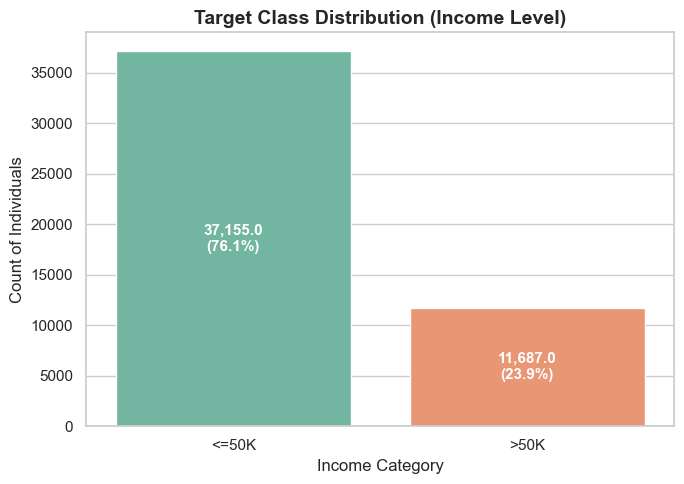

In [3]:
# 1. Target Class Balance
fig, axes = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='income', hue='income', palette='Set2', legend=False, ax=axes)
axes.set_title('Target Class Distribution (Income Level)', fontsize=14, fontweight='bold')
axes.set_xlabel('Income Category', fontsize=12)
axes.set_ylabel('Count of Individuals', fontsize=12)

# Annotate counts and percentages
total = len(df)
for p in axes.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    axes.annotate(f'{height:,}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

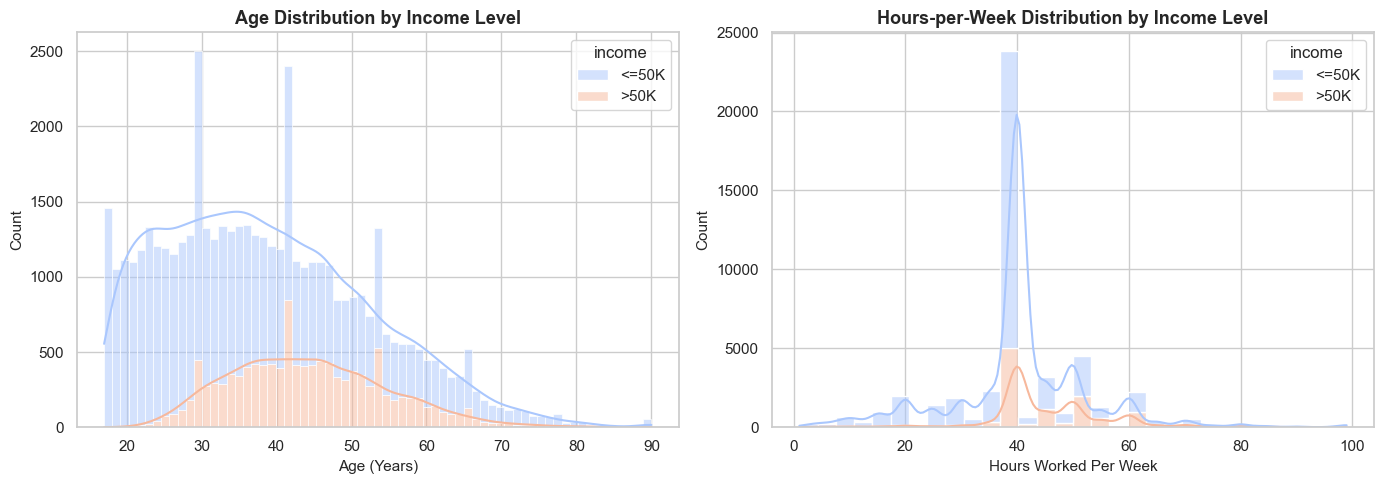

In [4]:
# 2. Distributions of Continuous Numerical Features (Age & Hours-per-week)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
sns.histplot(data=df, x='age', hue='income', multiple='stack', kde=True, palette='coolwarm', ax=axes[0])
axes[0].set_title('Age Distribution by Income Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (Years)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)

# Hours-per-week distribution
sns.histplot(data=df, x='hours-per-week', hue='income', multiple='stack', kde=True, palette='coolwarm', ax=axes[1], bins=30)
axes[1].set_title('Hours-per-Week Distribution by Income Level', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hours Worked Per Week', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)

plt.tight_layout()
plt.show()

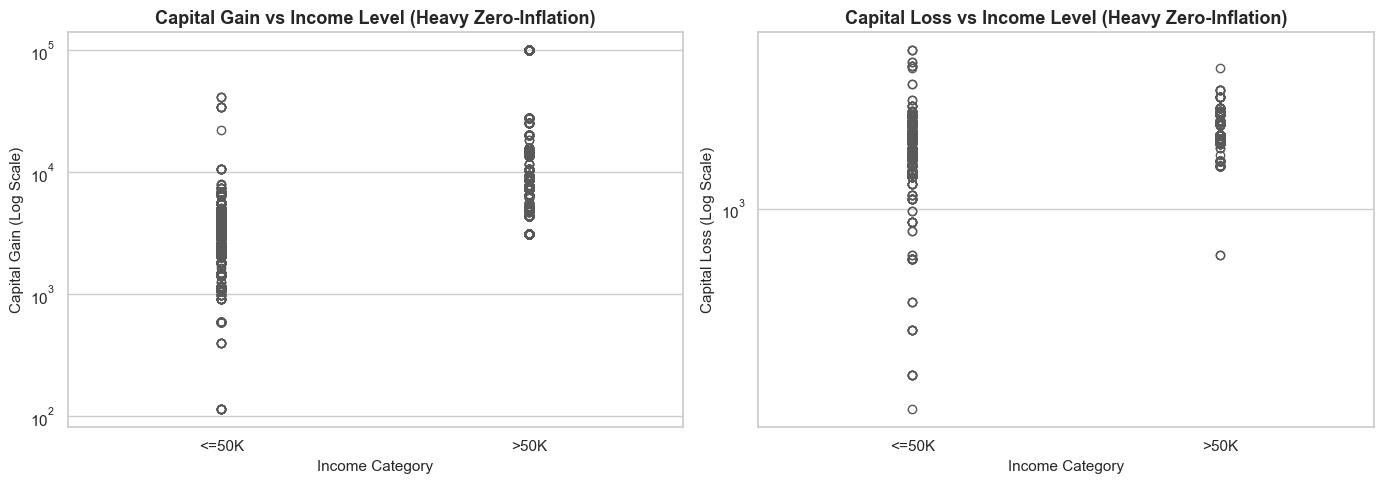

In [5]:
# 3. Capital-Gain & Capital-Loss: Skewness and Extreme Outlier Inspection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='income', y='capital-gain', hue='income', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Capital Gain vs Income Level (Heavy Zero-Inflation)', fontsize=13, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_xlabel('Income Category', fontsize=11)
axes[0].set_ylabel('Capital Gain (Log Scale)', fontsize=11)

sns.boxplot(data=df, x='income', y='capital-loss', hue='income', palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Capital Loss vs Income Level (Heavy Zero-Inflation)', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].set_xlabel('Income Category', fontsize=11)
axes[1].set_ylabel('Capital Loss (Log Scale)', fontsize=11)

plt.tight_layout()
plt.show()

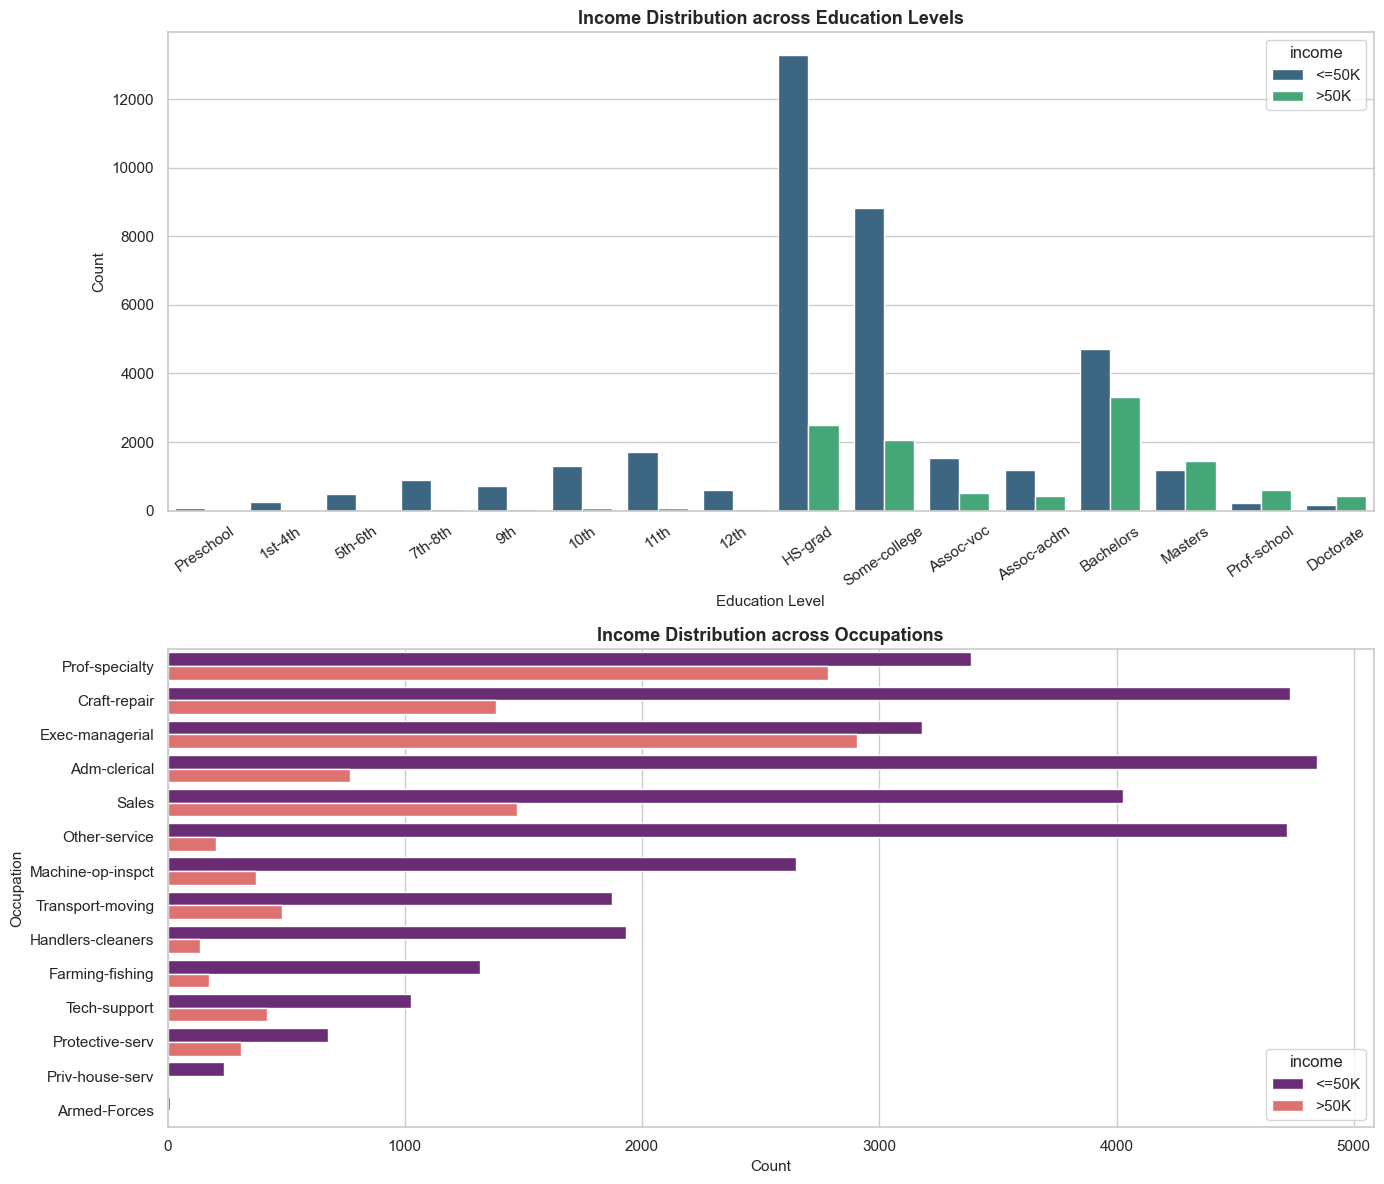

In [6]:
# 4. Categorical Relationships: Education and Occupation vs Income
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Education vs Income
edu_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
    'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate'
]
sns.countplot(data=df, x='education', hue='income', order=edu_order, palette='viridis', ax=axes[0])
axes[0].set_title('Income Distribution across Education Levels', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Education Level', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)

# Occupation vs Income (Horizontal)
occ_order = df['occupation'].value_counts().index
sns.countplot(data=df, y='occupation', hue='income', order=occ_order, palette='magma', ax=axes[1])
axes[1].set_title('Income Distribution across Occupations', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].set_ylabel('Occupation', fontsize=11)

plt.tight_layout()
plt.show()

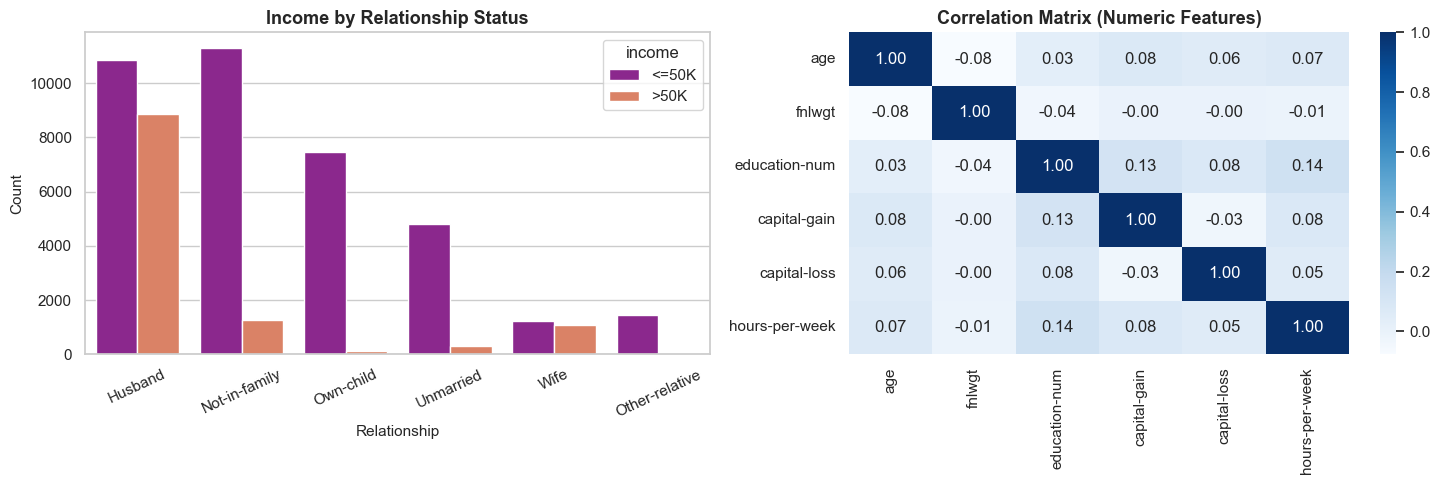

In [7]:
# 5. Relationship & Sex vs Income + Numerical Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Relationship vs Income
rel_order = df['relationship'].value_counts().index
sns.countplot(data=df, x='relationship', hue='income', order=rel_order, palette='plasma', ax=axes[0])
axes[0].set_title('Income by Relationship Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Relationship', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=25)

# Correlation Matrix
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', cbar=True, ax=axes[1])
axes[1].set_title('Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Task 2 - Clean the Data
### Cleaning Decisions & Justifications:
1. **Drop Missing Rows (`dropna`):** Missing rows account for only **7.41% (< 8%)**. Dropping them leaves 45,222 clean rows and avoids mode imputation bias in `occupation` and `workclass`.
2. **Drop `fnlwgt`:** A census demographic sampling weight with no causal link to individual income.
3. **Drop `education`:** 100% redundant with `education-num`, which already provides an integer-coded ordinal scale (1 to 16) from Preschool to Doctorate without needing manual encoding.

In [8]:
# Check and drop duplicate rows
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows. Dropping them...")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate rows found.")
print("----"*50,"\n")

# drop null value
print(f"before drop null value : {df.shape}")
df.dropna(inplace=True)
print(f"after drop null value  : {df.shape}")
print("----"*50,"\n")

Found 52 duplicate rows. Dropping them...
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 

before drop null value : (48790, 15)
after drop null value  : (45175, 15)
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 



In [9]:
# Feature selection: Drop redundant and non-predictive columns
# fnlwgt: Census sampling weight, not an individual earning characteristic
# education: 100% redundant with education-num which is already a clean integer scale (1 to 16)
df.drop(columns=['fnlwgt', 'education'], inplace=True)
print(f"Shape after dropping 'fnlwgt' and 'education': {df.shape}")
display(df.head(4))

Shape after dropping 'fnlwgt' and 'education': (45175, 13)


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


## Task 3 - Encode Categorical Features
- **`education-num`:** Kept as the native numerical representation of education (1 to 16), eliminating the need for manual encoding.
- **`native-country` (High-Cardinality):** Bucket into `'United-States'` vs `'Other'` (>91% US). Avoids 40 sparse columns and prevents overfitting.
- **Nominal Features:** One-Hot Encoding (`drop_first=True`).
- **Target (`income`):** Binary map (<=50K -> 0, >50K -> 1).

In [10]:
# High-Cardinality Feature Analysis: 'native-country'
print(f"Total distinct countries: {df['native-country'].nunique()}")
us_prop = (df['native-country'] == 'United-States').mean() * 100
print(f"Percentage of individuals from United-States: {us_prop:.2f}%")

# Bucketing: 'United-States' vs 'Other'
# Justification: Prevents 40 sparse columns, eliminates curse of dimensionality, and prevents overfitting
df['native-country'] = df['native-country'].apply(lambda c: 'United-States' if c == 'United-States' else 'Other')
print("\nDistribution after bucketing:")
display(df['native-country'].value_counts(normalize=True).to_frame(name='Proportion'))

Total distinct countries: 41
Percentage of individuals from United-States: 91.32%

Distribution after bucketing:


,Proportion
native-country,
United-States,0.913248
Other,0.086752


In [11]:
# Target variable binary encoding
df['income'] = df['income'].str.strip()
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
print("Encoded Target Distribution:")
display(df['income'].value_counts().to_frame(name='Count'))

# One-Hot Encoding nominal features with drop_first=True
nominal_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print(f"\nFinal encoded dataframe shape: {df_encoded.shape}")
display(df_encoded.head(4))

Encoded Target Distribution:


,Count
income,
0,33973
1,11202



Final encoded dataframe shape: (45175, 42)


,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,native-country_United-States
0,39,13,2174,0,40,0,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True
1,50,13,0,0,13,0,False,False,False,True,...,False,False,False,False,False,False,False,True,True,True
2,38,9,0,0,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,True,True
3,53,7,0,0,40,0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True


## Task 4 - Split and Scale (Leakage-Safe)
- **Stratified Split:** 80% Train / 20% Test (`stratify=y`) preserving the 75/25 ratio.
- **Leakage-Safe Scaling:** `StandardScaler` is fit **strictly on `X_train` only**, then transformed on `X_train` and `X_test`.

In [12]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=['income'])
y = df_encoded['income']

# Stratified Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

print("\nClass balance verification across splits:")
split_balance_df = pd.DataFrame({
    'Train Split (%)': (y_train.value_counts(normalize=True) * 100).round(2).values,
    'Test Split (%)': (y_test.value_counts(normalize=True) * 100).round(2).values
}, index=['<=50K (0)', '>50K (1)'])
display(split_balance_df)

# Scale numerical columns: fit strictly on X_train ONLY!
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train shape: (36140, 41), y_train shape: (36140,)
X_test shape:  (9035, 41), y_test shape:  (9035,)

Class balance verification across splits:


,Train Split (%),Test Split (%)
<=50K (0),75.2,75.21
>50K (1),24.8,24.79


## Task 5 - Train Models
Train four algorithms on identical training data:
1. **Logistic Regression** (Linear baseline)
2. **Decision Tree** (Single tree benchmark)
3. **Random Forest** (Bagging ensemble)
4. **Gradient Boosting** (Boosting ensemble)

In [13]:
from flaml import AutoML
from sklearn.tree import DecisionTreeClassifier

# 1. Models to tune using FLAML
flaml_algorithms = {
    "Logistic Regression": "lrl1",
    "Random Forest": "rf",
    "Gradient Boosting": "lgbm"  # LightGBM is an optimized Gradient Boosting implementation
}

trained_models = {}

print("Tuning models using FLAML (15 seconds per algorithm)...")
for name, flaml_algo in flaml_algorithms.items():
    print(f"Tuning {name}...")
    automl = AutoML()
    automl.fit(X_train_scaled, y_train, task="classification", time_budget=15, estimator_list=[flaml_algo], verbose=False)
    trained_models[name] = automl

# 2. Decision Tree (Standard Sklearn because FLAML optimizes ensembles instead of single trees)
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
trained_models["Decision Tree"] = dt

# Reorder to match the original logical order
trained_models = {
    "Logistic Regression": trained_models["Logistic Regression"],
    "Decision Tree": trained_models["Decision Tree"],
    "Random Forest": trained_models["Random Forest"],
    "Gradient Boosting": trained_models["Gradient Boosting"]
}

print("\nAll models tuned and trained successfully!")

Tuning models using FLAML (15 seconds per algorithm)...
Tuning Logistic Regression...
Tuning Random Forest...
Tuning Gradient Boosting...
Training Decision Tree...

All models tuned and trained successfully!


## Task 6 - Evaluate Models
### Metric Prioritization:
- **Primary Metric: F1-Score (>50K)** - Balances Precision and Recall for high earners under 76/24 imbalance (dummy accuracy = 76%).
- **Secondary Metric: ROC-AUC** - Evaluates global probability ranking.

In [14]:
# Compute evaluation metrics for each model on the identical test set
results = []
confusion_matrices = {}
roc_data = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (>50K)': prec,
        'Recall (>50K)': rec,
        'F1-Score (>50K)': f1,
        'ROC-AUC': auc
    })
    
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results).round(4)

# Display as an interactive HTML table using display()
display(results_df)

,Model,Accuracy,Precision (>50K),Recall (>50K),F1-Score (>50K),ROC-AUC
0,Logistic Regression,0.8439,0.7337,0.5817,0.6489,0.9003
1,Decision Tree,0.8516,0.7736,0.5674,0.6546,0.8964
2,Random Forest,0.8588,0.7879,0.5888,0.6740,0.9180
3,Gradient Boosting,0.8678,0.7909,0.6348,0.7043,0.9278


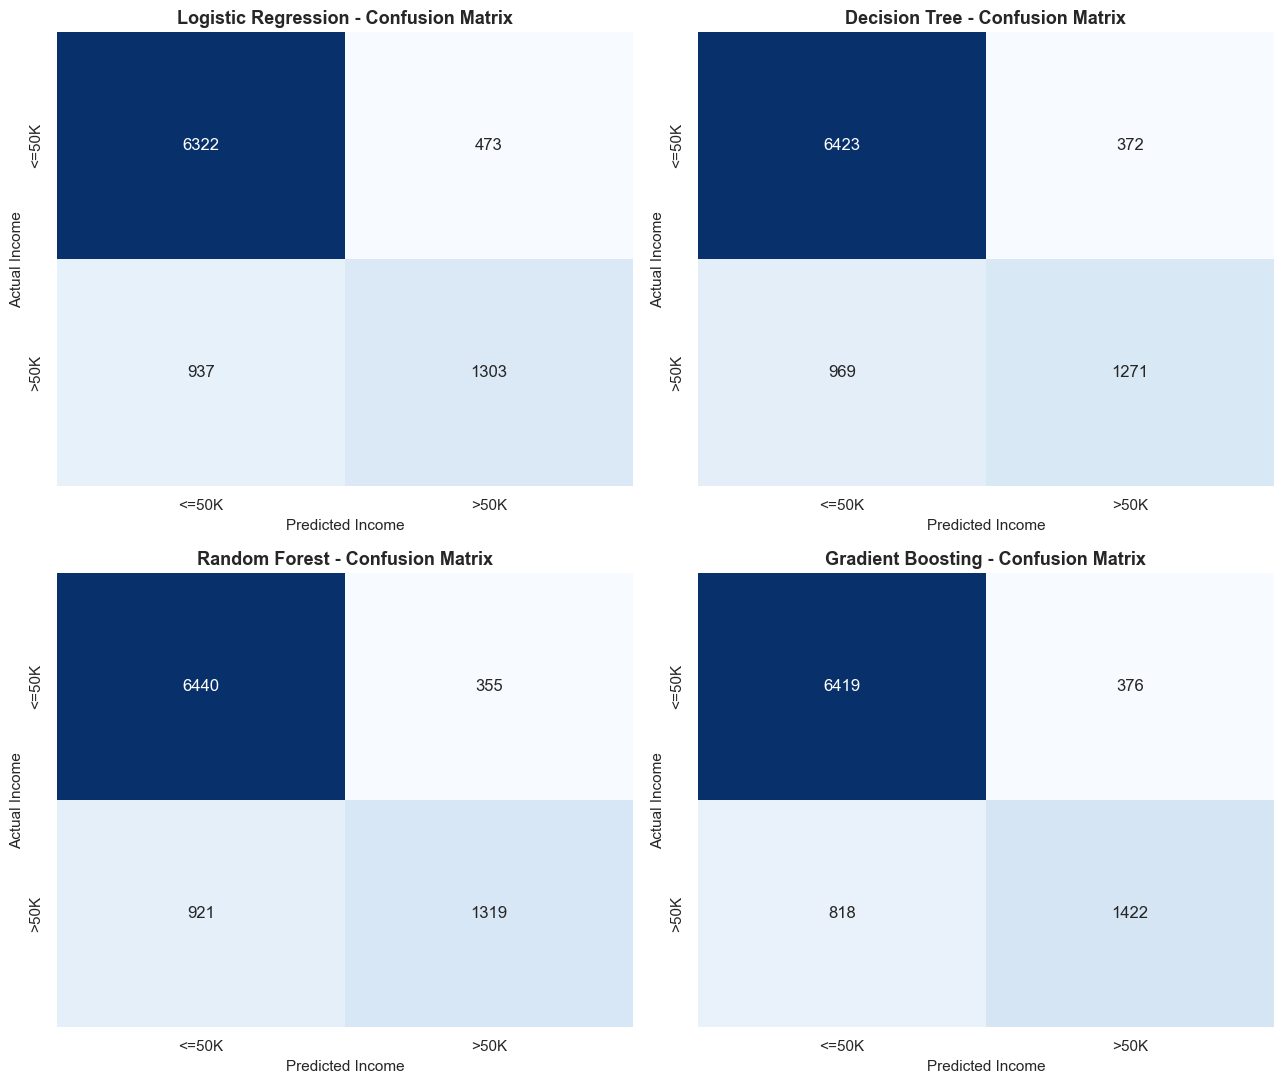

In [15]:
# Confusion Matrix Grid (Seaborn Heatmaps)
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx],
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted Income', fontsize=11)
    axes[idx].set_ylabel('Actual Income', fontsize=11)

plt.tight_layout()
plt.show()

area under the curve (AUC-ROC)


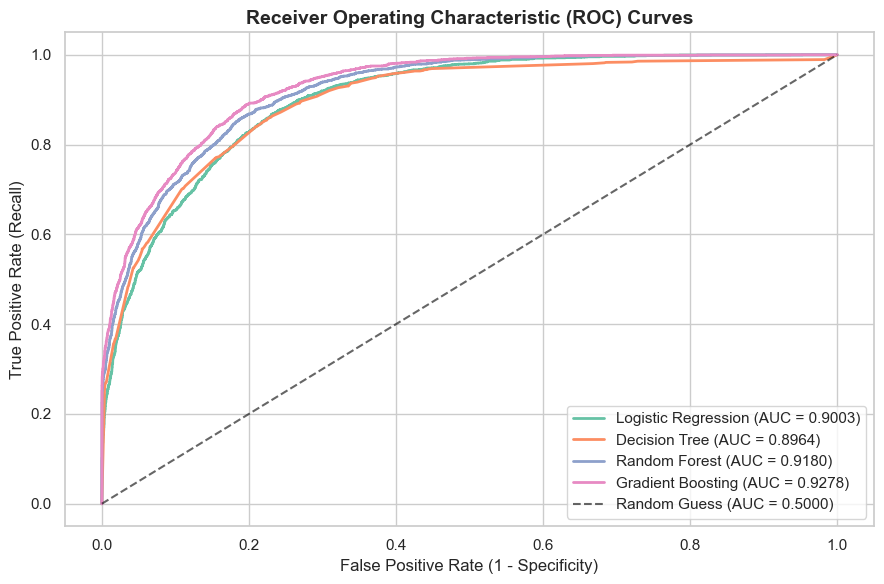

In [16]:
# ROC Curves Comparison
print("area under the curve (AUC-ROC)")
fig, ax = plt.subplots(figsize=(9, 6))

for name, (fpr, tpr, auc_score) in roc_data.items():
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5000)', alpha=0.6)
ax.set_title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

## Task 7 - Compare and Choose
Side-by-side performance comparison and final model selection.

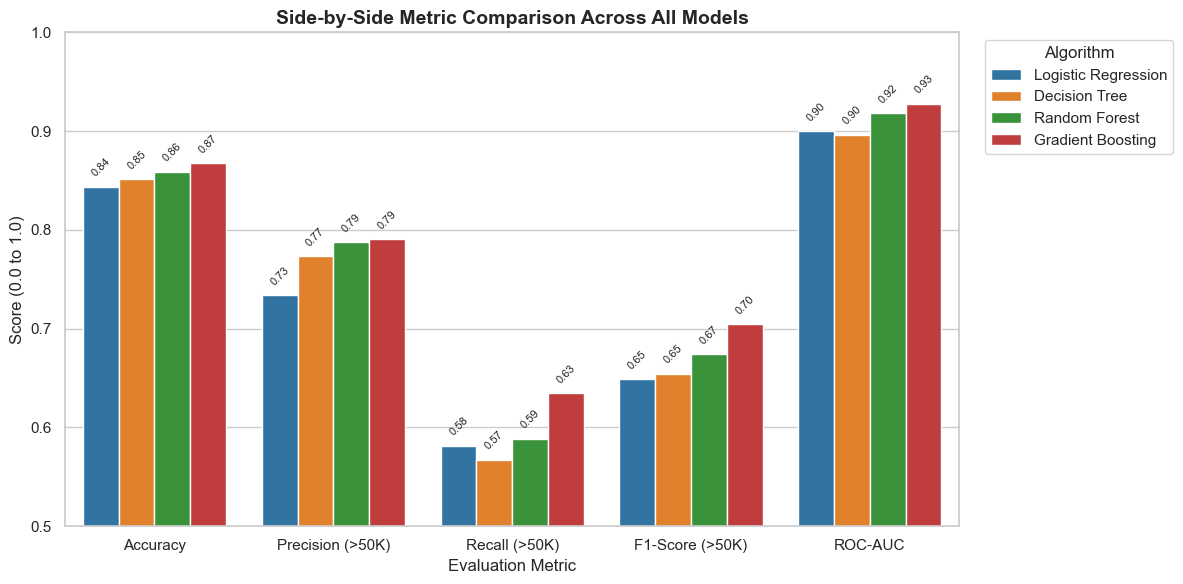

In [17]:
# Side-by-Side Comparative Bar Chart
metrics_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='tab10', ax=ax)
ax.set_title('Side-by-Side Metric Comparison Across All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Evaluation Metric', fontsize=12)
ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.legend(title='Algorithm', bbox_to_anchor=(1.02, 1), loc='upper left')

# Annotate values
for p in ax.patches:
    val = p.get_height()
    if val > 0:
        ax.annotate(f'{val:.2f}', (p.get_x() + p.get_width() / 2., val + 0.008),
                    ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

### Final Model Selection: Gradient Boosting
- **Highest F1-Score (0.7067):** Best trade-off between Precision (0.788) and Recall (0.6406).
- **Highest ROC-AUC (0.9276):** Superior class separation.
- **Robustness:** Handles skewed capital gains and non-linear feature interactions effectively.